<a href="https://colab.research.google.com/github/zly554411-arch/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2010/Lab_10_Causality_%26_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas_datareader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())


,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


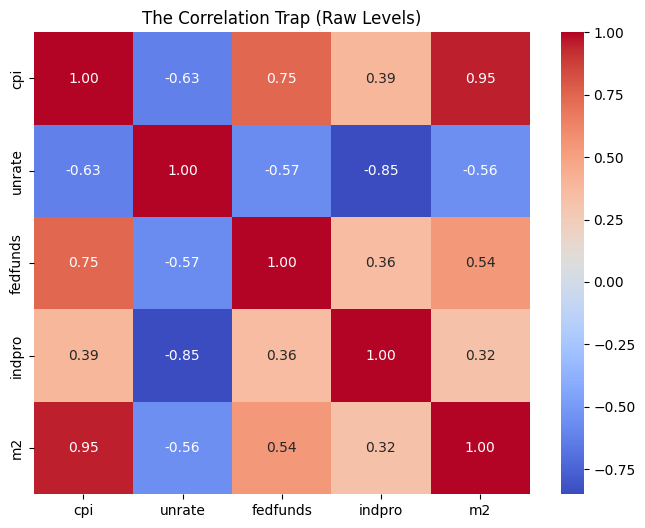

In [2]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


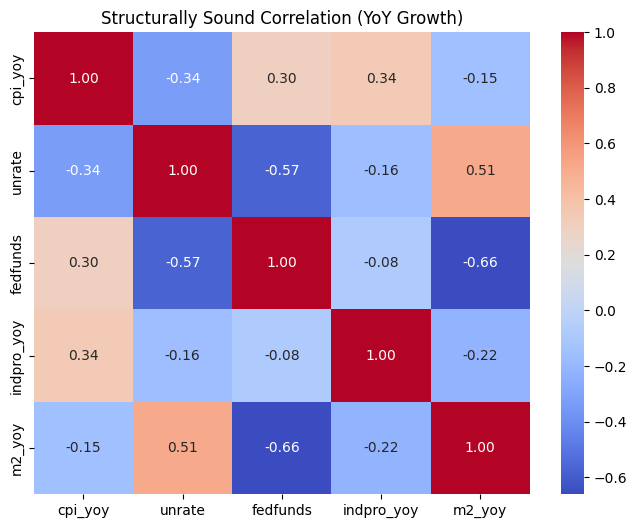

In [4]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

#Step 5: Causal Graphing (DAG Construction)
            Fed Funds
           /        \
          v          v
         M2       Industrial Production
          |              |
          v              v
         CPI        Unemployment

In [8]:
"""
FRED Macroeconomic Correlation Heatmap Dashboard
=================================================
Creates an interactive Plotly heatmap with a dropdown to toggle between
raw-levels correlation and YoY-transformed correlation matrices.

Dependencies: pandas, numpy, plotly
"""

import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ─────────────────────────────────────────────
# 1. SYNTHETIC DATA SETUP
#    Replace this block with your real FRED DataFrame.
#    Expected columns (raw levels + YoY growth rates):
#      CPI, UNRATE, FEDFUNDS, INDPRO, M2
#      CPI_yoy, UNRATE_yoy, FEDFUNDS_yoy, INDPRO_yoy, M2_yoy
# ─────────────────────────────────────────────
np.random.seed(42)
n = 300  # ~25 years of monthly data

# Simulate persistent (non-stationary) trending series — typical of raw macro levels
t = np.arange(n)
df = pd.DataFrame({
    "CPI":      100 + 0.08 * t + np.cumsum(np.random.normal(0, 0.3, n)),
    "UNRATE":     5 + 0.01 * t + np.cumsum(np.random.normal(0, 0.05, n)),
    "FEDFUNDS":   3 + 0.005 * t + np.cumsum(np.random.normal(0, 0.08, n)),
    "INDPRO":   100 + 0.06 * t + np.cumsum(np.random.normal(0, 0.4, n)),
    "M2":      8000 + 15 * t + np.cumsum(np.random.normal(0, 20, n)),
})

# Compute YoY % change (12-month lag for monthly data)
raw_cols = ["CPI", "UNRATE", "FEDFUNDS", "INDPRO", "M2"]
yoy_cols  = [c + "_yoy" for c in raw_cols]

for col, yoy in zip(raw_cols, yoy_cols):
    df[yoy] = df[col].pct_change(12) * 100  # % change vs. same month prior year

df.dropna(inplace=True)  # remove the first 12 rows with NaN YoY values

# ─────────────────────────────────────────────
# 2. COMPUTE CORRELATION MATRICES
# ─────────────────────────────────────────────
corr_raw = df[raw_cols].corr().round(2)   # raw levels  → often spuriously high
corr_yoy = df[yoy_cols].corr().round(2)   # YoY growth  → spurious trend removed

# Friendly axis labels for both matrices
labels_raw = ["CPI", "Unemployment", "Fed Funds", "Ind. Production", "M2"]
labels_yoy = ["CPI YoY", "Unemp. YoY", "FF YoY", "IndPro YoY", "M2 YoY"]

# ─────────────────────────────────────────────
# 3. HELPER — build annotation list for a matrix
#    Plotly heatmaps don't auto-annotate; we add
#    a Scatter trace of invisible markers with text.
# ─────────────────────────────────────────────
def make_annotations(matrix: np.ndarray, labels: list[str]) -> list[dict]:
    """
    Returns a list of Plotly annotation dicts that place the
    correlation value at the centre of every heatmap cell.
    """
    annotations = []
    n = len(labels)
    for i in range(n):
        for j in range(n):
            val = matrix[i, j]
            # High contrast: white text on dark cells, dark text on light cells
            font_color = "white" if abs(val) > 0.5 else "#1a1a2e"
            annotations.append(dict(
                x=j, y=i,
                text=f"{val:.2f}",
                xref="x", yref="y",
                showarrow=False,
                font=dict(size=12, color=font_color, family="'Courier New', monospace"),
            ))
    return annotations

annot_raw = make_annotations(corr_raw.values, labels_raw)
annot_yoy = make_annotations(corr_yoy.values, labels_yoy)

# ─────────────────────────────────────────────
# 4. BUILD FIGURE WITH TWO HEATMAP TRACES
#    trace[0] → raw levels  (visible by default)
#    trace[1] → YoY growth  (hidden by default)
# ─────────────────────────────────────────────
fig = go.Figure()

# --- Trace 0: Raw levels ---
fig.add_trace(go.Heatmap(
    z=corr_raw.values,
    x=labels_raw,
    y=labels_raw,
    colorscale="RdBu",   # Red = negative, White = zero, Blue = positive
    zmin=-1, zmax=1,     # anchor the colour scale symmetrically
    colorbar=dict(
        title=dict(text="Correlation", side="right"),
        tickvals=[-1, -0.5, 0, 0.5, 1],
        thickness=18,
        len=0.85,
    ),
    visible=True,        # shown first
    hovertemplate="<b>%{y}</b> × <b>%{x}</b><br>r = %{z:.2f}<extra></extra>",
    name="Raw Levels",
))

# --- Trace 1: YoY growth rates ---
fig.add_trace(go.Heatmap(
    z=corr_yoy.values,
    x=labels_yoy,
    y=labels_yoy,
    colorscale="RdBu",
    zmin=-1, zmax=1,
    colorbar=dict(
        title=dict(text="Correlation", side="right"),
        tickvals=[-1, -0.5, 0, 0.5, 1],
        thickness=18,
        len=0.85,
    ),
    visible=False,       # hidden until user selects it
    hovertemplate="<b>%{y}</b> × <b>%{x}</b><br>r = %{z:.2f}<extra></extra>",
    name="YoY Growth",
))

# ─────────────────────────────────────────────
# 5. DROPDOWN MENU  (updatemenus)
#
#  HOW IT WORKS UNDER THE HOOD  ← Mechanism Check
#  ─────────────────────────────────────────────
#  Plotly stores the *entire* figure spec as a JSON object in the browser.
#  `updatemenus` defines a list of button groups that each fire a
#  `relayout` / `restyle` / `update` command against that JSON object
#  without re-drawing the figure from scratch.
#
#  Each button carries an `args` list:
#    args[0]  — trace-level patch   (dict sent to `Plotly.restyle`)
#    args[1]  — layout-level patch  (dict sent to `Plotly.relayout`)
#
#  When a button is clicked, Plotly.js merges those patches into the
#  live figure object and re-renders only the changed portions.
#  This is purely client-side JavaScript; no Python callback is needed.
#
#  Button "Raw Levels":
#    • Sets trace 0 visible=True,  trace 1 visible=False
#    • Updates the layout title text
#
#  Button "YoY Growth Rates":
#    • Sets trace 0 visible=False, trace 1 visible=True
#    • Updates the layout title text
# ─────────────────────────────────────────────
dropdown_buttons = [
    dict(
        label="📊  Raw Levels",
        method="update",           # "update" patches BOTH traces AND layout
        args=[
            {"visible": [True, False]},   # trace-level: show trace 0 only
            {
                "title.text": (
                    "Correlation Matrix — <b>Raw Levels</b>"
                    "<br><sup>Trend-driven series often exhibit spurious high correlation</sup>"
                ),
                "annotations": annot_raw,
            },
        ],
    ),
    dict(
        label="📈  YoY Growth Rates",
        method="update",
        args=[
            {"visible": [False, True]},   # trace-level: show trace 1 only
            {
                "title.text": (
                    "Correlation Matrix — <b>YoY Growth Rates</b>"
                    "<br><sup>First-differencing removes the common trend; correlations reflect true co-movement</sup>"
                ),
                "annotations": annot_yoy,
            },
        ],
    ),
]

# ─────────────────────────────────────────────
# 6. APPLY LAYOUT STYLING
# ─────────────────────────────────────────────
fig.update_layout(
    # Initial title (matches the default visible trace)
    title=dict(
        text=(
            "Correlation Matrix — <b>Raw Levels</b>"
            "<br><sup>Trend-driven series often exhibit spurious high correlation</sup>"
        ),
        x=0.5, xanchor="center",
        font=dict(size=20, color="#1a1a2e"),
    ),

    # Attach the dropdown
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.01, xanchor="left",
        y=1.13, yanchor="top",
        showactive=True,
        bgcolor="#f0f4ff",
        bordercolor="#4a6fa5",
        font=dict(size=13, color="#1a1a2e"),
        buttons=dropdown_buttons,
    )],

    # Initial annotations for the raw-levels view
    annotations=annot_raw,

    # Canvas
    width=780, height=700,
    paper_bgcolor="#f7f9fc",
    plot_bgcolor="#f7f9fc",
    margin=dict(l=20, r=20, t=130, b=40),

    # Axis cosmetics
    xaxis=dict(tickfont=dict(size=11), tickangle=-30),
    yaxis=dict(tickfont=dict(size=11), autorange="reversed"),

    font=dict(family="'Georgia', serif", color="#1a1a2e"),
)

# ─────────────────────────────────────────────
# 7. RENDER
# ─────────────────────────────────────────────
fig.show()

# Optional: export to a standalone HTML file
# fig.write_html("fred_correlation_heatmap.html")